In [109]:
%pylab inline
pylab.rcParams['figure.figsize'] = (18, 8)

import pandas as pd
import random
import statistics
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/Users/julienaudoux/Desktop/WORK(lab)/forecasting_models/.venv/lib/python3.10/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [110]:
type_target = 'arrivees_urgences'
assert type_target in ['hospitalisations', 'arrivees_urgences']

In [111]:
if type_target == 'hospitalisations':
    '''
    df = pd.read_csv('target.csv', sep=';')
    '''
    df = pd.read_csv('RPU_vers_hospit_adultes.csv', sep=';')
    df['date_entree'] = pd.to_datetime(df['date_entree'], format="%d/%m/%Y")
    df.rename({'Total': type_target}, axis=1, inplace=True)
    df['target'] = df[type_target].copy()
    # on ajoute les arrivées aux urgences, que l'on suppose connues pour le jour J
    dff = pd.read_feather('CHU Dijon_volumes.feather')
    dff.rename({'Total': 'arrivees_urgences'}, axis=1, inplace=True)
    dff.reset_index(inplace=True)
    df = pd.merge(df, dff, on='date_entree')
else:
    df = pd.read_feather('CHU Dijon_volumes.feather')
    df.rename({'Total': type_target}, axis=1, inplace=True)

In [112]:
# On ajoute la target
if type_target == 'hospitalisations':
    horizon = 7
else:
    horizon = 3
df['mean'] = df[type_target].rolling(window=horizon, min_periods=1).mean()
df['target'] = df['mean'].shift(-2*horizon+1)
df.drop('mean', axis=1, inplace=True)
df.dropna(inplace=True)
df.shape

(2186, 4)

In [113]:
# On ajoute les features
dg = pd.read_csv('features_all_origin.csv', sep=',')
dg.drop('Total', axis=1, inplace=True)
dg['date_entree'] = pd.to_datetime(dg['date_entree'], format="%Y-%m-%d")
dff = pd.merge(df, dg, on='date_entree', how='left')
dff.set_index('date_entree', inplace=True)

<Axes: xlabel='date_entree'>

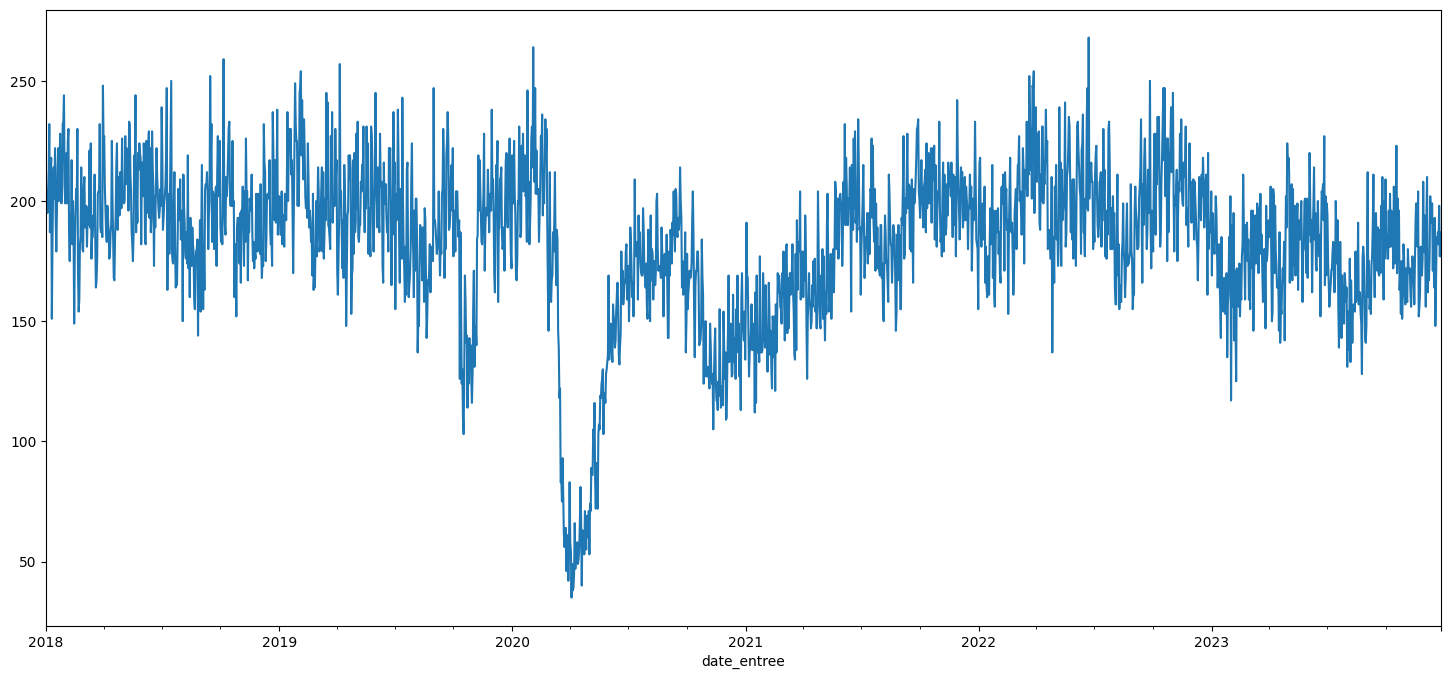

In [114]:
df[type_target].plot()

In [115]:
dff

,arrivees_urgences,nom_etablissement_x,total_CHU Dijon,target,bankHolidays,eveBankHolidays,holidays,borderHolidays,confinement1,confinement2,...,total_CHU Dijon_J-1,total_CHU Dijon_J-2,total_CHU Dijon_J-3,total_CHU Dijon_J-4,total_CHU Dijon_J-5,total_CHU Dijon_J-6,total_CHU Dijon_J-7,total_CHU Dijon_mean,total_CHU Dijon_std,total_CHU Dijon_derivative
date_entree,,,,,,,,,,,,,,,,,,,,,
2018-01-01,212,CHU Dijon,212,211.666667,1.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,196,CHU Dijon,196,208.666667,0.0,0.0,1.0,0.0,0.0,0.0,...,212.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,195,CHU Dijon,195,210.333333,0.0,0.0,1.0,0.0,0.0,0.0,...,196.0,212.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-16.0
2018-01-04,196,CHU Dijon,196,205.666667,0.0,0.0,1.0,0.0,0.0,0.0,...,195.0,196.0,212.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
2018-01-05,207,CHU Dijon,207,193.666667,0.0,0.0,1.0,0.0,0.0,0.0,...,196.0,195.0,196.0,212.0,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,182,CHU Dijon,182,176.333333,0.0,0.0,0.0,1.0,0.0,0.0,...,187.0,183.0,185.0,165.0,148.0,193.0,164.0,175.000000,16.237816,4.0
2023-12-23,198,CHU Dijon,198,178.000000,0.0,0.0,1.0,0.0,0.0,0.0,...,182.0,187.0,183.0,185.0,165.0,148.0,193.0,177.571429,15.618975,-5.0
2023-12-24,177,CHU Dijon,177,171.333333,0.0,1.0,1.0,0.0,0.0,0.0,...,198.0,182.0,187.0,183.0,185.0,165.0,148.0,178.285714,16.529915,16.0


In [116]:
dff.drop('nom_etablissement_x', axis=1, inplace=True)
dff.drop('nom_etablissement_y', axis=1, inplace=True)
dff.drop('HNFC_moving', axis=1, inplace=True)
dff.drop('total_CHU Dijon', axis=1, inplace=True)
dff.drop('target', axis=1, inplace=True)
dff.fillna(0, inplace=True)
dff = dff.T

In [117]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA

# prep = MaxAbsScaler()
# kmeans = KMeans(n_clusters=4, random_state=0)



In [118]:
dff

date_entree,2018-01-01,2018-01-02,2018-01-03,2018-01-04,2018-01-05,2018-01-06,2018-01-07,2018-01-08,2018-01-09,2018-01-10,...,2023-12-17,2023-12-18,2023-12-19,2023-12-20,2023-12-21,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26
arrivees_urgences,212.0,196.0,195.0,196.0,207.0,232.0,187.0,212.000000,218.000000,151.000000,...,148.000000,165.000000,185.000000,183.000000,187.000000,182.000000,198.000000,177.000000,187.000000,177.000000
bankHolidays,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
eveBankHolidays,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
holidays,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
borderHolidays,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
total_CHU Dijon_J-6,0.0,0.0,0.0,0.0,0.0,0.0,212.0,196.000000,195.000000,196.000000,...,194.000000,199.000000,171.000000,191.000000,164.000000,193.000000,148.000000,165.000000,185.000000,183.000000
total_CHU Dijon_J-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,212.000000,196.000000,195.000000,...,191.000000,194.000000,199.000000,171.000000,191.000000,164.000000,193.000000,148.000000,165.000000,185.000000
total_CHU Dijon_mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,203.571429,203.571429,206.714286,...,186.142857,180.000000,175.857143,173.857143,175.571429,175.000000,177.571429,178.285714,182.428571,185.571429
total_CHU Dijon_std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.020621,15.020621,15.467323,...,13.171036,19.183326,18.783225,16.516947,16.791438,16.237816,15.618975,16.529915,10.030905,6.477066


In [119]:
# scaled_data = prep.fit_transform(dff)
# kmeans.fit(scaled_data)

prep = MaxAbsScaler()
scaled_data = prep.fit_transform(dff)


pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)



In [120]:
from sklearn.metrics import silhouette_score
biggest = (0, 0) # (n_cluster, silhouette_score)
for n_cluster in range(2, 10):
    kmeans = KMeans(n_clusters=n_cluster, random_state=0)
    kmeans.fit(pca_data)
    score = silhouette_score(pca_data, kmeans.labels_)
    if score > biggest[1]:
        biggest = (n_cluster, score)
    print(n_cluster, score)
print(biggest)

2 0.9138561940423235
3 0.9271210732399194
4 0.9323887371526374
5 0.9243029573033376
6 0.9285322152793175
7 0.9318574800443663
8 0.8927589485333339
9 0.8931927764250966
(4, 0.9323887371526374)


In [121]:
kmeans = KMeans(n_clusters=biggest[0], random_state=0)
kmeans.fit(pca_data)

KMeans(n_clusters=4, random_state=0)

In [122]:
cluster_0 = []
for cluster in range(kmeans.n_clusters):
    print(f"Cluster {cluster}")
    cluster_data = dff[kmeans.labels_ == cluster]
    #for i in range(min(5, cluster_data.shape[0])):
    for i in range(cluster_data.shape[0]):
        if cluster == 0:
            cluster_0.append(cluster_data.index[i])
        print(cluster_data.index[i])
    print()

Cluster 0
arrivees_urgences
bankHolidays
eveBankHolidays
holidays
borderHolidays
confinement1
confinement2
couvrefeux
ramadan
inc_grippe_derivative
inc_diarrhee_derivative
inc_varicelle
inc_varicelle_J-1
inc_varicelle_J-2
inc_varicelle_J-3
inc_varicelle_J-4
inc_varicelle_J-5
inc_varicelle_J-6
inc_varicelle_J-7
inc_varicelle_J-8
inc_varicelle_J-9
inc_varicelle_J-10
inc_varicelle_J-11
inc_varicelle_J-12
inc_varicelle_J-13
inc_varicelle_J-14
inc_varicelle_J-15
inc_varicelle_J-16
inc_varicelle_J-17
inc_varicelle_J-18
inc_varicelle_J-19
inc_varicelle_J-20
inc_varicelle_J-21
inc_varicelle_mean
inc_varicelle_std
inc_varicelle_derivative
inc_ira_derivative
trend_diarrhée
trend_vomissements
trend_toux
trend_éruption cutanée
trend_infection urinaire
trend_hopital
trend_médecin
trend_pharmacie
trend_médicament
trend_vaccin
trend_maladie
trend_fièvre
trend_grippe
trend_rhume
trend_angine
trend_otite
trend_allergie
trend_asthme
trend_stress
trend_dépression
trend_mal de tête
trend_douleur thoraciqu

In [123]:
# print the cluster of the type_target
print(kmeans.predict(pca.transform(prep.transform(dff.T[type_target].values.reshape(1, -1)))))

[0]


In [124]:
#%pip install tsfresh

In [125]:
# from tsfresh import extract_features
# from tsfresh.feature_extraction import MinimalFCParameters
# df = dff.T
# df = data[['Date', 'unique_id', 'Sessions']]
# extracted_features = extract_features(df, column_id='unique_id', column_sort='Date', default_fc_parameters=MinimalFCParameters())

In [126]:

for cluster in range(kmeans.n_clusters):
    print(f"Cluster {cluster}")
    cluster_data = dff[kmeans.labels_ == cluster]
    #for i in range(min(5, cluster_data.shape[0])):
    for i in range(cluster_data.shape[0]):
        print(cluster_data.index[i])
    print()

Cluster 0
arrivees_urgences
bankHolidays
eveBankHolidays
holidays
borderHolidays
confinement1
confinement2
couvrefeux
ramadan
inc_grippe_derivative
inc_diarrhee_derivative
inc_varicelle
inc_varicelle_J-1
inc_varicelle_J-2
inc_varicelle_J-3
inc_varicelle_J-4
inc_varicelle_J-5
inc_varicelle_J-6
inc_varicelle_J-7
inc_varicelle_J-8
inc_varicelle_J-9
inc_varicelle_J-10
inc_varicelle_J-11
inc_varicelle_J-12
inc_varicelle_J-13
inc_varicelle_J-14
inc_varicelle_J-15
inc_varicelle_J-16
inc_varicelle_J-17
inc_varicelle_J-18
inc_varicelle_J-19
inc_varicelle_J-20
inc_varicelle_J-21
inc_varicelle_mean
inc_varicelle_std
inc_varicelle_derivative
inc_ira_derivative
trend_diarrhée
trend_vomissements
trend_toux
trend_éruption cutanée
trend_infection urinaire
trend_hopital
trend_médecin
trend_pharmacie
trend_médicament
trend_vaccin
trend_maladie
trend_fièvre
trend_grippe
trend_rhume
trend_angine
trend_otite
trend_allergie
trend_asthme
trend_stress
trend_dépression
trend_mal de tête
trend_douleur thoraciqu

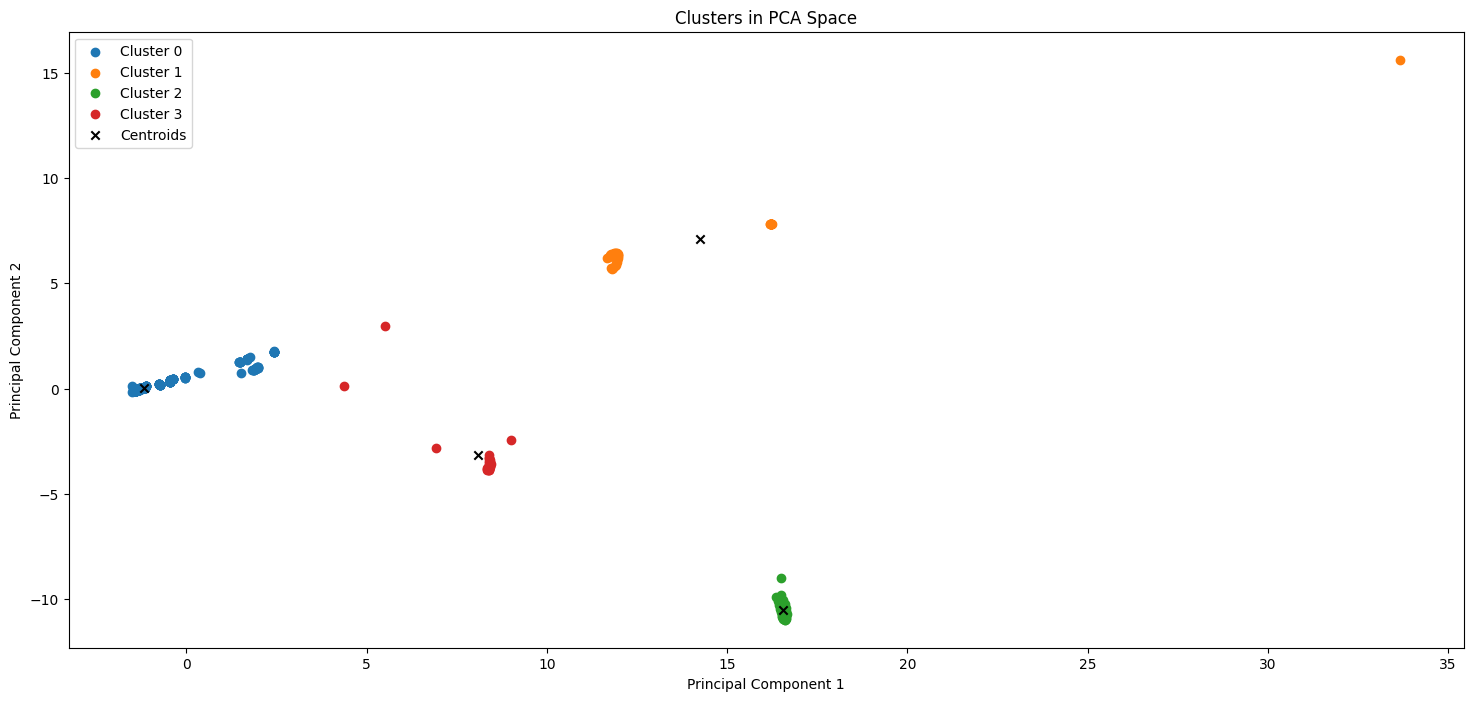

In [127]:
import matplotlib.pyplot as plt

for cluster in range(kmeans.n_clusters):
    cluster_points = pca_data[kmeans.labels_ == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster}")

# Plot the cluster centroids as black 'X' markers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='x', label='Centroids')

plt.title("Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

# Display the plot
plt.show()

In [128]:
#%pip install tslearn

In [129]:
# from tslearn.clustering import TimeSeriesKMeans, silhouette_score
# kmeans = TimeSeriesKMeans(n_clusters=4, metric="dtw")
# labels = kmeans.fit_predict(pca_data)
# silhouette_score(pca_data, labels, metric="dtw")

In [130]:
prep = MaxAbsScaler()
dff = dff.T[cluster_0]
dff = dff.T
scaled_data = prep.fit_transform(dff)


pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)


kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(pca_data)


KMeans(n_clusters=4, random_state=0)

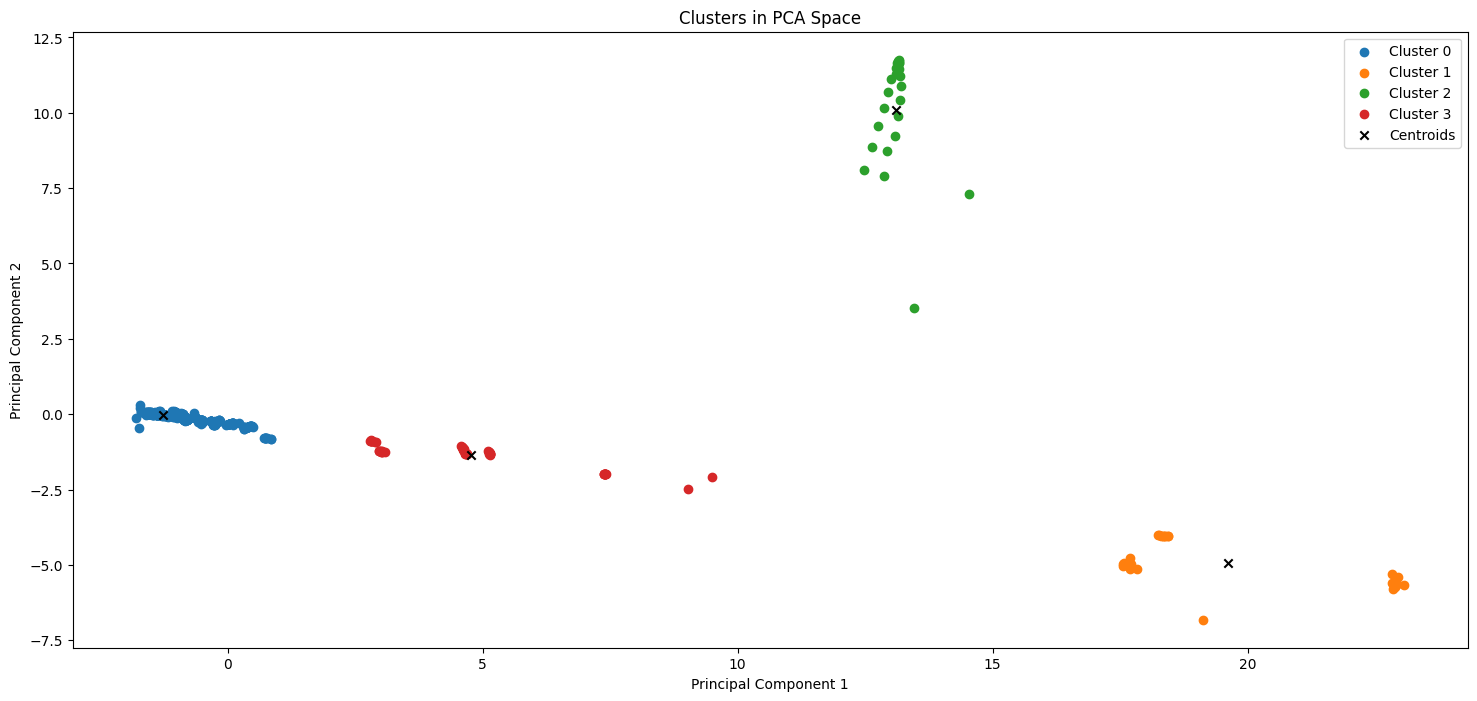

In [131]:
for cluster in range(kmeans.n_clusters):
    cluster_points = pca_data[kmeans.labels_ == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster}")

# Plot the cluster centroids as black 'X' markers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='x', label='Centroids')

plt.title("Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

# Display the plot
plt.show()